<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 2.1 PyCBC Tutorial, An introduction to matched-filtering

We will be using the [PyCBC](https://pycbc.org) library, which is used to study gravitational-wave data, find astrophysical sources due to compact binary mergers, and study their parameters. These are some of the same tools that the LIGO and Virgo collaborations use to find gravitational waves in LIGO/Virgo data

In this tutorial we will walk through how to find a specific signal in LIGO data. We present matched filtering as a cross-correlation, in both the time domain and the frequency domain. In the next tutorial (2.2), we use the method as encoded in PyCBC, which is optimal in the case of Gaussian noise and a known signal model. In reality our noise is not entirely Gaussian, and in practice we use a variety of techniques to separate signals from noise in addition to the use of the matched filter.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/Day_2/Tuto_2.1_Matched_filtering_introduction.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).

See [additional examples](https://pycbc.org/pycbc/latest/html/#library-examples-and-interactive-tutorials) and [documentation](https://pycbc.org/pycbc/latest/html/index.html).

# Cómo encontrar una señal específica en datos LIGO.


1.  Se usará el filtrado adaptado como una correlación cruzada, tanto en el dominio temporal como en el frecuencial.

### Tutorial (2.2)

2.   Se usará el método codificado en PyCBC, que es óptimo en el caso del ruido gaussiano y un modelo de señal conocido.

En realidad, nuestro ruido no es completamente gaussiano, y en la práctica, además del filtro adaptado, utilizamos diversas técnicas para separar las señales del ruido

In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".

In [2]:
# -- Use the following for Google Colab
#! pip install -q 'lalsuite==7.25' 'PyCBC==2.4.1'
! pip install -q PyCBC==2.4.1 lalsuite==7.25
!pip install numpy==1.23.5

## Matched-filtering: Finding well modelled signals in Gaussian noise


Matched filtering can be shown to be the optimal method for "detecting" _known_ signals in _Gaussian_ noise. We'll explore those two assumptions a little later, but for now let's demonstrate how this works.

Let's assume you have a stretch of noise, white noise to start:


#Usamos Matched-filtering
Es el método óptimo para detectar señales _conocidas_ en ruido _gaussiano_

# Información relevante:


*   La frecuencia de muestreo (**SAMPLE RATE**): Es cuántas veces por segundo se mide una señal continua para convertirla en una señal digital. Se mide en Hz (ciclos por segundo o muestras por segundo).




*  **16384 Hz (=2^14 samples/second):** =  Significa que LIGO toman 16384 muestras por segundo de la señal continua de onda gravitacional. Este valor es alto porque quieren capturar detalles finos en señales que pueden tener frecuencias muy altas.
*   **f_Nyquist = 8192 Hz:** La frecuencia de Nyquist es la mitad de la frecuencia de muestreo. Es el límite superior de las frecuencias que se pueden capturar correctamente con un muestreo dado, sin que se produzca aliasing (una distorsión de la señal).Entonces, si LIGO muestrea a 16384 Hz, puede detectar ondas de hasta 8192 Hz con fidelidad.



*  **sampling at a lower rate:** Reducir la frecuencia de muestreo a, por ejemplo, 4096 Hz (o incluso 2048 Hz) reduce el tamaño de los datos y hace que las operaciones sean más rápidas, a costa de perder contenido en las frecuencias más altas.


In [3]:
import numpy
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib.pyplot as plt
import pylab


## ESPECIFICAMOS EL SAMPLE RATE

# specify the sample rate.
# LIGO raw data is sampled at 16384 Hz (=2^14 samples/second).
# It captures signal frequency content up to f_Nyquist = 8192 Hz.
# Here, we will make the computation faster by sampling at a lower rate.

sample_rate = 1024 # samples per second
data_length = 1024 # seconds




# Generamos Ruido Blanco: La serie de datos y la serie de tiempo

In [4]:

# Generate a long stretch of white noise: the data series and the time series.

data = numpy.random.normal(size=[sample_rate * data_length])
times = numpy.arange(len(data)) / float(sample_rate)

And then let's add a gravitational wave signal to some random part of this data.


# Agregamos los datos de la onda gravitacional de alguna parte random

Para agregarlos usamos el comando:


---


pycbc.waveform.waveform.get_td_waveform(template=None, **kwargs)



---


Que nos arroja las polarizaciones Plus  $h_+$  y Cross $h_{\times}$ en el dominio del tiempo de la forma de onda.

Se pueden agregar diferentes parametros como masas, espines, excentricidad, etc.


In [5]:
from pycbc.waveform import get_td_waveform

# the "approximant" (jargon for parameterized waveform family).
# IMRPhenomD(a phenomenological Inspiral–Merger–Ringdown wafeform model) is defined in the frequency domain, but we'll get it in the time domain (td).
# It runs fast, but it doesn't include effects such as non-aligned component spin, or higher order modes.
apx = 'IMRPhenomD'

Reference for [IMRPhenomD](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.93.044006). You can specify [many parameters](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html?highlight=get_td_waveform#pycbc.waveform.waveform.get_td_waveform), but here, we'll use defaults for everything except the masses.

`get_td_waveform` returns both $h_+$ and $h_{\times}$, but we'll only use $h_+$ for now.



# Usaremos solo la polarización $h_+$; y el el modelo IMRPhenomD
Pero trabajando en el dominio del tiempo, y no de las frecuencias. Perdemos informacion de espines u ordenenes superiores pero ganamos tiempo de ejecución.

In [6]:
hp1, _ = get_td_waveform(approximant=apx,  #approximant es la jerga para indicar a la familia de formas de onda parametrizadas
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/sample_rate,
                         f_lower=25)

La **amplitud de la señal de la Onda Gravitacional** es del orden de **$10^{-20}$**

Para demostrar nuestro metodo sobre Ruido Blanco con amplitud $O(1)$:


*   Normalizamos  la señal de tal forma que la cross-correlation de la señal consigo misma arroje un valor de 1
*   Si arroja el valor de 1, entonces interpretamos la cross-correlation de la señal con Ruido Blando como una relación SEÑAL-RUIDO



The amplitude of gravitational-wave signals is normally of order $10^{-20}$. To demonstrate our method on white noise with amplitude $O(1)$ we normalize our signal so the cross-correlation of the signal with itself will give a value of 1.

In this case we can interpret the cross-correlation of the signal with white noise as a signal-to-noise ratio.

In [7]:
hp1 = hp1 / max(numpy.correlate(hp1, hp1, mode='full'))**0.5

Text(0, 0.5, 'Normalized amplitude')

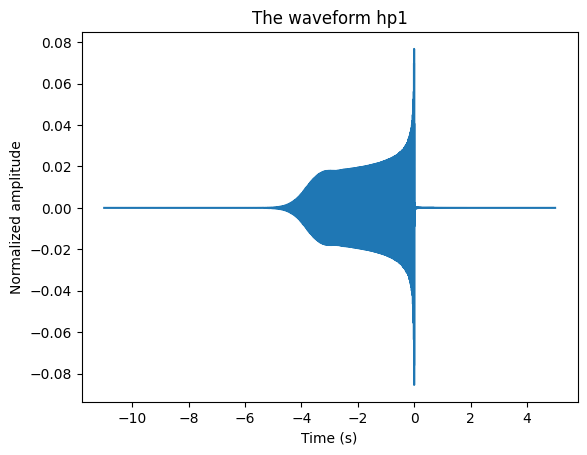

In [8]:
# Tenga en cuenta que en esta figura, la amplitud de la forma de onda es de orden 1.
# La duración (para frecuencias superiores a f_lower=25 Hz) es de solo 3 o 4 segundos.
# La forma de onda es "cónica": aumenta gradualmente desde cero hasta su intensidad máxima, durante aproximadamente el primer segundo.
# Se rellena con ceros en los primeros momentos.

plt.figure()
plt.title("The waveform hp1")
plt.plot(hp1.sample_times, hp1)
plt.xlabel('Time (s)')
plt.ylabel('Normalized amplitude')

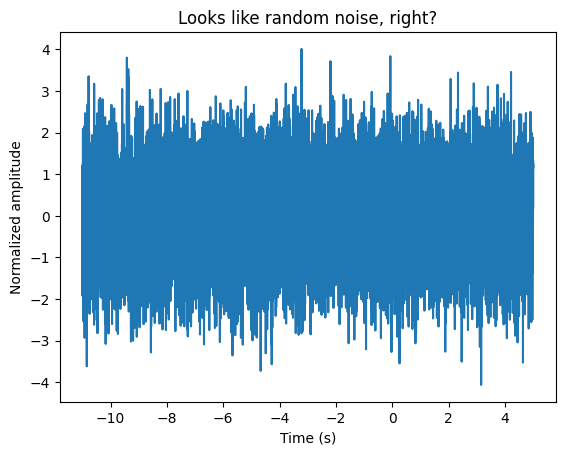

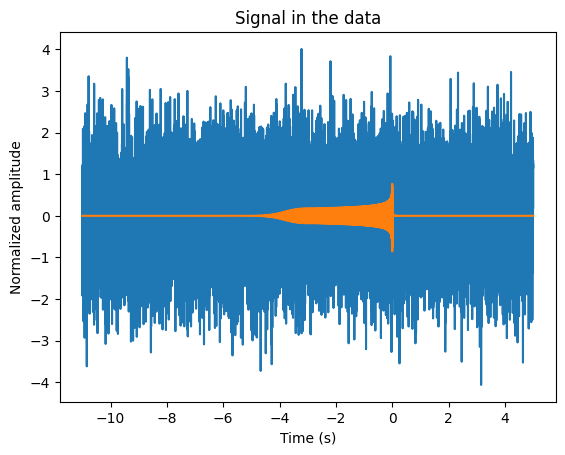

In [9]:
# Cambia la forma de onda para que comience en un momento aleatorio en los datos de ruido gaussiano.

waveform_start = numpy.random.randint(0, len(data) - len(hp1))
data[waveform_start:waveform_start+len(hp1)] += 10 * hp1.numpy()

plt.figure()
plt.title("Looks like random noise, right?")
plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
plt.xlabel('Time (s)')
plt.ylabel('Normalized amplitude')

plt.figure()
plt.title("Signal in the data")
plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
plt.plot(hp1.sample_times, 10 * hp1) # Esta linea es la que hace la diferencia para identificar la señal
plt.xlabel('Time (s)')
plt.ylabel('Normalized amplitude')
plt.show()

In [10]:
# note that in this figure, the waveform amplitude is of order 1.
# The duration (for frequency above f_lower=25 Hz) is only 3 or 4 seconds long.
# The waveform is "tapered": slowly ramped up from zero to full strength, over the first second or so.
# It is zero-padded at earlier times.

#plt.figure()
#plt.title("The waveform hp1")
#plt.plot(hp1.sample_times, hp1)
#plt.xlabel('Time (s)')
#plt.ylabel('Normalized amplitude')


# Shift the waveform to start at a random time in the Gaussian noise data.

#waveform_start = numpy.random.randint(0, len(data) - len(hp1))
#data[waveform_start:waveform_start+len(hp1)] += 10 * hp1.numpy()

#plt.figure()
#plt.title("Looks like random noise, right?")
#plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
#plt.xlabel('Time (s)')
#plt.ylabel('Normalized amplitude')

#plt.figure()
#plt.title("Signal in the data")
#plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
#plt.plot(hp1.sample_times, 10 * hp1)
#plt.xlabel('Time (s)')
#plt.ylabel('Normalized amplitude')
#plt.show()

Para **buscar esta señal**


1.   Realizamos una **correlación cruzada** con todo el conjunto de datos. No está optimizado en este momento, solo se muestra el método.
2.   Realizamos la correlación cruzada **en el dominio temporal**, una vez por cada paso de tiempo.

El proceso es lento...



#¿Cómo funciona la Relación Cruzada (Cross-Correlation)?

El siguiente código realiza un análisis de correlación cruzada entre una señal (hp1) y un conjunto de datos (data).

Es una técnica común en el análisis de datos de ondas gravitacionales para encontrar coincidencias entre una plantilla teórica de onda y los datos experimentales.

In [11]:
#Definimos un arreglo de ceros para la CROSS-CORRELATION de longitud


#Se crea un arreglo cross_correlation lleno de ceros, con longitud igual a la cantidad de posiciones posibles donde hp1 puede "encajar" dentro de data.
#Esto es: si data tiene 1000 puntos y hp1 tiene 100, habrá 900 posiciones donde puedes alinear hp1 con data y calcular una correlación.

cross_correlation = numpy.zeros([len(data)-len(hp1)])


#Se convierte hp1 (que probablemente era un tensor de PyTorch o similar) a un arreglo de NumPy, porque las operaciones de NumPy se usan en el bucle.
hp1_numpy = hp1.numpy()


#Este bucle "desliza" la señal hp1_numpy a lo largo de data.

#En cada paso i, toma un fragmento de data del mismo tamaño que hp1_numpy:
#data[i:i+len(hp1_numpy)]

#Luego realiza una multiplicación punto a punto entre ese fragmento de data y hp1_numpy.

#El .sum() suma todos los productos: eso da una medida de cuánto se parece ese fragmento de data a hp1_numpy.

for i in range(len(data) - len(hp1_numpy)):
    cross_correlation[i] = (hp1_numpy * data[i:i+len(hp1_numpy)]).sum()



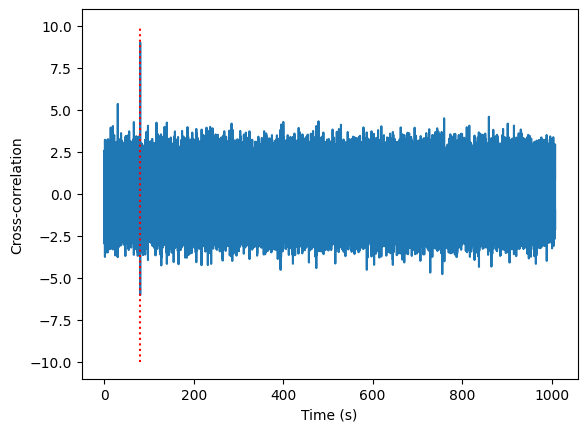

In [12]:
# Graficar los datos correlacionados en función del tiempo. Superponer la ubicación del final de la señal;
# Aquí es donde deberíamos encontrar un pico en la correlación cruzada.

plt.figure()

times = numpy.arange(len(data) - len(hp1_numpy)) / float(sample_rate)  # Creamos el eje temporal (times)
#numpy.arange(len(data) - len(hp1_numpy)) genera índices desde 0 hasta el número de valores de cross_correlation.
#Al dividir por sample_rate, conviertes los índices a tiempo real (en segundos),
#si por ejemplo tienes 4096 muestras por segundo, cada paso representa 1/4096 segundos.


plt.plot(times, cross_correlation) #Grafica la correlacion en función del tiempo. Mostrará en qué momento en el tiempo la plantilla hp1 se parece más a un fragmento de los datos.



#Dibuja una línea vertical roja punteada en el tiempo waveform_start/sample_rate.
#waveform_start probablemente indica el índice donde se espera que comience la onda gravitacional en los datos.
#Esto te ayuda a ver si el pico de la correlación se alinea con ese tiempo esperado

plt.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)], [-10,10],'r:')


plt.xlabel('Time (s)')
plt.ylabel('Cross-correlation')
plt.show()

¿Cómo entendemos este gráfico?

*   El eje horizontal es tiempo (en segundos).
*   El eje vertical muestra cuánto se parece cada fragmento de los datos a la señal teórica (hp1).
*   Si hay un pico alto, indica una coincidencia fuerte (posible detección de una onda gravitacional).
*   Una línea roja vertical indica dónde se espera la señal. Si coincide con el pico, ¡excelente!




### Detection in Colored Noise
# Detección en Ruido Coloreado

*   El pico mas largo de la cross-correlation se produce al momento de la señal
*   **Colored Noise** (Ruido Coloreado) es el ruido gaussiano, pero con una varianza dependiente de la frecuencia; el ruido blanco tiene una varianza independiente de la frecuencia.


¿Cómo es el Proceso?
*  Genera un tramo de datos coloreado con la curva de ruido de alta potencia y desintonización a cero de LIGO. Usaremos la biblioteca PyCBC

( stretch of data colored with LIGO's zero-detuned--high-power noise curve)







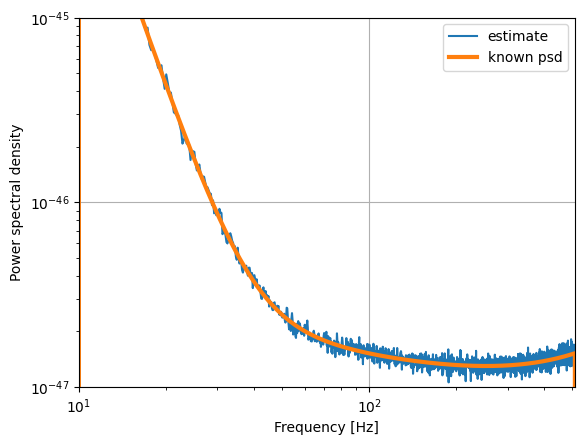

In [13]:
 # https://pycbc.org/pycbc/latest/html/noise.html
import pycbc.noise
import pycbc.psd

# The color of the noise matches a PSD which you provide:
# Generate a PSD matching Advanced LIGO's zero-detuned--high-power noise curve
flow = 10.0
delta_f = 1.0 / 128
flen = int(sample_rate / (2 * delta_f)) + 1
psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Generate colored noise
delta_t = 1.0 / sample_rate
ts = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed=127)

# Estimate the amplitude spectral density (ASD = sqrt(PSD)) for the noisy data
# using the "welch" method. We'll choose 4 seconds PSD samples that are overlapped 50%
seg_len = int(4 / delta_t)
seg_stride = int(seg_len / 2)
estimated_psd = pycbc.psd.welch(ts,seg_len=seg_len,seg_stride=seg_stride)

# plot it:
plt.loglog(estimated_psd.sample_frequencies, estimated_psd, label='estimate')
plt.loglog(psd.sample_frequencies, psd, linewidth=3, label='known psd')
plt.xlim(xmin=flow, xmax=512)
plt.ylim(1e-47, 1e-45)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power spectral density')
plt.legend()
plt.grid()
plt.show()

# add the signal, this time, with a "typical" amplitude.
ts[waveform_start:waveform_start+len(hp1)] += hp1.numpy() * 1E-20

Then all we need to do is to "whiten" both the data, and the template waveform. This can be done, in the frequency domain, by dividing by the PSD. This *can* be done in the time domain as well, but it's more intuitive in the frequency domain

Para "blanquear" los dos conjuntos de datos y el template de la forma de onda, debemos dividir entre la PSD; esto si estamos en el dominio de frecuencias.

El blanqueamiento puede hacerse en el dominio del tiempo, pero es más intuitivo en el de frecuencias

#Blanqueamiento de los Datos

In [18]:
# Generate a PSD for whitening the data
from pycbc.types import TimeSeries

# The PSD, sampled properly for the noisy data
flow = 10.0
delta_f = 1.0 / data_length
flen = int(sample_rate / (2 * delta_f)) + 1
psd_td = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The PSD, sampled properly for the signal
delta_f = sample_rate / float(len(hp1))
flen = int(sample_rate / (2 * delta_f)) + 1
psd_hp1 = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The 0th and Nth values are zero. Set them to a nearby value to avoid dividing by zero.
psd_td[0] = psd_td[1]
psd_td[len(psd_td) - 1] = psd_td[len(psd_td) - 2]
# Same, for the PSD sampled for the signal
psd_hp1[0] = psd_hp1[1]
psd_hp1[len(psd_hp1) - 1] = psd_hp1[len(psd_hp1) - 2]

# convert both noisy data and the signal to frequency domain,
# and divide each by ASD=PSD**0.5, then convert back to time domain.
# This "whitens" the data and the signal template.
# Multiplying the signal template by 1E-21 puts it into realistic units of strain.
data_whitened = (ts.to_frequencyseries() / psd_td**0.5).to_timeseries()
hp1_whitened = (hp1.to_frequencyseries() / psd_hp1**0.5).to_timeseries() * 1E-21

# Re-hacemos la correlacion en el dominio del tiempo, pero usando los datos blanqueados y el template

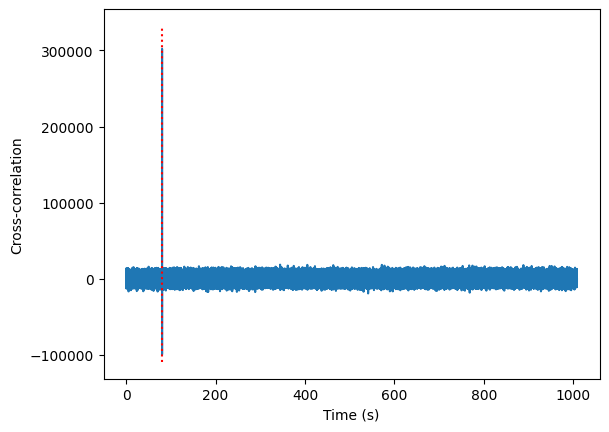

In [15]:
# Now let's re-do the correlation, in the time domain, but with whitened data and template.
cross_correlation = numpy.zeros([len(data)-len(hp1)])
hp1n = hp1_whitened.numpy()
datan = data_whitened.numpy()
for i in range(len(datan) - len(hp1n)):
    cross_correlation[i] = (hp1n * datan[i:i+len(hp1n)]).sum()

# plot the cross-correlation in the time domain. Superimpose the location of the end of the signal.
# Note how much bigger the cross-correlation peak is, relative to the noise level,
# compared with the unwhitened version of the same quantity. SNR is much higher!
plt.figure()
times = numpy.arange(len(datan) - len(hp1n)) / float(sample_rate)
plt.plot(times, cross_correlation)
plt.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)],
           [(min(cross_correlation))*1.1,(max(cross_correlation))*1.1],'r:')
plt.xlabel('Time (s)')
plt.ylabel('Cross-correlation')
plt.show()

# Challenge!

* Histogram the whitened time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation? (We have not been careful in normalizing the whitened data properly).
* Histogram the above cross-correlation time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation?
* (Optional) Find the location of the peak. (Note that here, it can be positive or negative), and the value of the SNR of the signal (which is the absolute value of the peak value, divided by the standard deviation of the cross-correlation time series).

Histogram the whitened time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation? (We have not been careful in normalizing the whitened data properly).

data_whitened.data.std = 22.475344722704385


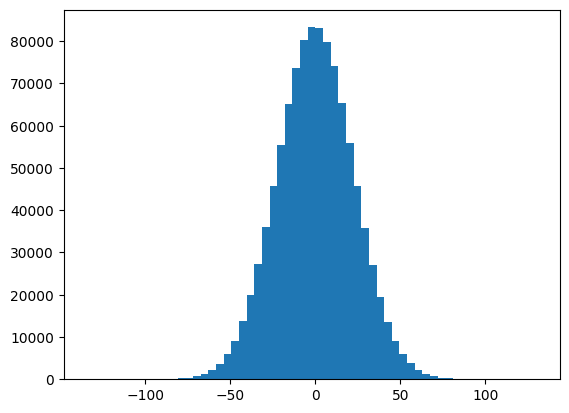

In [16]:
datastd = data_whitened.data.std()
pylab.hist(data_whitened.data, bins=numpy.arange(-6,6,0.2)*datastd)
print('data_whitened.data.std =',datastd)

#Respuesta 25

Histogram the above cross-correlation time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation?



cross_correlation.std = 3986.2792735473313


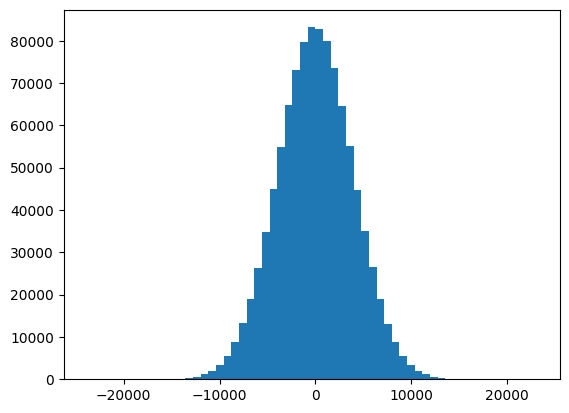

In [17]:
ccstd = cross_correlation.std()
pylab.hist(cross_correlation, bins=numpy.arange(-6,6,0.2)*ccstd)
print('cross_correlation.std =',ccstd)

#despuesta: deviation 3986

(Optional) Find the location of the peak. (Note that here, it can be positive or negative), and the value of the SNR of the signal (which is the absolute value of the peak value, divided by the standard deviation of the cross-correlation time series).